# Libraries

In [37]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sci
from sklearn.metrics import r2_score
import pickle

# Dataset upload and computing error model

### $x$ data

In [38]:
filename = r'C:\git-projetos\2025-2_andre_rimes\gen_dataset\z_dataset_2_wexp_menos_wfib2020.pkl'
with open(filename, 'rb') as f:
    dataset_x = pickle.load(f)

### $y$ data

In [39]:
data = pd.read_excel(r'C:\git-projetos\2025-2_andre_rimes\gen_dataset\data_models_rv2.xlsx', sheet_name='Modelos')
data.columns = data.columns.str.lower().str.replace(' ', '-')
data

,autor,output:-w_exp-(mm),fib-model-code-2020-(mm),wexp_menos_wfib2020,fib-model-code-2020--com-ts-variável-(mm),wexp_menos_wfib2020ts,norma-chinesa-(mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),0.16,0.086159,0.073841,0.102130,0.057870,NaN
1,NaN,0.23,0.147127,0.082873,0.190783,0.039217,NaN
2,NaN,0.24,0.155568,0.084432,0.203058,0.036942,NaN
3,NaN,0.27,0.196838,0.073162,0.263069,0.006931,NaN
4,NaN,0.35,0.277502,0.072498,0.380363,-0.030363,NaN
...,...,...,...,...,...,...,...
336,NaN,0.19,0.217911,-0.027911,0.227492,-0.037492,NaN
337,NaN,0.22,0.247400,-0.027400,0.261534,-0.041534,NaN
338,Viga 23-6-11-2 - Clark (1956),0.17,0.150622,0.019378,0.150622,0.019378,NaN
339,Viga 23-6-11-3 - Clark (1956),0.19,0.108061,0.081939,0.108061,0.081939,NaN


### PySR model

In [40]:
filename = r'C:\Users\wande\Downloads\drive-download-20260101T194945Z-1-001\results_pysr_model_8020_dataset_2.pkl'
with open(filename, 'rb') as f:
    results_pysr_model_8020_dataset_1 = pickle.load(f)
    results_pysr_model_8020_dataset_1 = results_pysr_model_8020_dataset_1[1:]

results_pysr_model_8020_dataset_1

c:\git-projetos\2025-2_andre_rimes\env\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\git-projetos\2025-2_andre_rimes\env\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\git-projetos\2025-2_andre_rimes\env\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using 

[{'diametro_da_armadura_mm': {'avg': 17.800882352941176,
   'std_dev': 6.438354908463468},
  'resistencia_do_aco_fy_mpa': {'avg': 468.2977941176471,
   'std_dev': 102.32511764477204},
  'resistencia_a_tracao_do_concreto_mpa': {'avg': 3.099253530886211,
   'std_dev': 0.5177369741107708},
  'cobrimento_mm': {'avg': 32.654411764705884, 'std_dev': 10.82500715016106},
  'distancia_ao_centro_de_gravidade_da_armadura_mm': {'avg': 43.49080882352941,
   'std_dev': 12.110460813301465},
  'area_de_aco_tracionada_as_mm2': {'avg': 678.5698529411765,
   'std_dev': 592.8923515797308},
  'taxa_de_armadura_conforme_mc2020': {'avg': 0.025807790641023797,
   'std_dev': 0.016181713979925055},
  'tensao_na_armadura_menos_tension_stiffening_variavel_mpa': {'avg': 247.8627229010383,
   'std_dev': 119.69882875069193},
  'fib_model_code_2010': {'avg': 0.21883114075307877,
   'std_dev': 0.08622931153483639},
  'eurocode_2': {'avg': 0.2250132930313585, 'std_dev': 0.07514653096527509},
  'nbr_6118_wk1_fissuracao_

In [41]:
dataset_x[1].columns

Index(['diametro_da_armadura_mm', 'resistencia_do_aco_fy_mpa',
       'resistencia_a_tracao_do_concreto_mpa', 'cobrimento_mm',
       'distancia_ao_centro_de_gravidade_da_armadura_mm',
       'area_de_aco_tracionada_as_mm2', 'taxa_de_armadura_conforme_mc2020',
       'tensao_na_armadura_menos_tension_stiffening_variavel_mpa',
       'fib_model_code_2010', 'eurocode_2',
       'nbr_6118_wk1_fissuracao_estabilizada',
       'nbr_6118_wk2_fissuracao_nao_estabilizada', 'clark_1956',
       'desayiganesan_1985', 'oh_kang_1987', 'caldas_1997',
       'gergely_e_lutz_1968', 'equacao_15_do_artigo_de_belarbi_e_hsu_1994',
       'beta_conforme_fields_e_bischoff_2004', 'slip_de_yuan_et_al_2025',
       'slip_de_biscaia_e_soares_2020'],
      dtype='object')

### See best equation by R2 and Z-score parameters

In [42]:
df_models = {
                'r2 train': [],
                'r2 test': [],
                'rmse train': [],
                'rmse test': [],
                'score': [],
                'best equation': [],
            }
for idx, item in enumerate(results_pysr_model_8020_dataset_1):
    model = item["model"]
    df_models['r2 train'].append(model["train_r2"])
    df_models['r2 test'].append(model["test_r2"])
    df_models['rmse train'].append(model["train_rmse"])
    df_models['rmse test'].append(model["test_rmse"])
    df_models['score'].append(model["model_object"].get_best()['score'])
    df_models['best equation'].append(model["best_equation"])
df_models = pd.DataFrame(df_models)
df_models['gap rmse'] = abs(df_models['rmse train'] - df_models['rmse test'])
df_models['gap r2'] = abs(df_models['r2 train'] - df_models['r2 test'])
# df_models = df_models.sort_values(by='gap rmse')
# df_models = df_models.sort_values(by='gap r2')
df_models = df_models.sort_values(by='r2 train', ascending=False)
df_models.head()

,r2 train,r2 test,rmse train,rmse test,score,best equation,gap rmse,gap r2
70,0.675130,0.494641,0.043224,0.046061,0.076168,((fib_model_code_2010 - (diametro_da_armadura_...,0.002837,0.180489
57,0.650467,0.467731,0.044404,0.049757,0.090605,(abs(equacao_15_do_artigo_de_belarbi_e_hsu_199...,0.005352,0.182736
75,0.648881,0.442838,0.044172,0.052207,0.114750,((eurocode_2 + (equacao_15_do_artigo_de_belarb...,0.008035,0.206043
23,0.622256,0.649643,0.045241,0.043992,0.057667,(area_de_aco_tracionada_as_mm2 + abs((slip_de_...,0.001249,0.027387
27,0.618553,0.540350,0.045900,0.048068,0.064560,((nbr_6118_wk2_fissuracao_nao_estabilizada - a...,0.002169,0.078204


In [43]:
equation = df_models.iloc[0]['best equation']
equation

'((fib_model_code_2010 - (diametro_da_armadura_mm + abs((resistencia_a_tracao_do_concreto_mpa + square(caldas_1997)) - ((equacao_15_do_artigo_de_belarbi_e_hsu_1994 - nbr_6118_wk1_fissuracao_estabilizada) * -4.105527)))) - ((equacao_15_do_artigo_de_belarbi_e_hsu_1994 - eurocode_2) / 0.25291178)) * -0.017529251'

In [44]:
best_index = df_models['r2 train'].idxmax()
best_index

70

In [45]:
def computing_equation(df, lista_colunas, lista_medias, lista_desvios):
    """
    Computes the PySR symbolic regression equation using z-score normalized inputs.
    """

    # --- Z-score normalization ---
    df_z = df.copy()
    for col, mi, sigma in zip(lista_colunas, lista_medias, lista_desvios):
        if sigma != 0:
            df_z[col] = (df[col] - mi) / sigma
        else:
            df_z[col] = 0.0

    # --- Variable mapping (normalized space) ---
    fib_2010   = df_z['fib_model_code_2010']
    diametro  = df_z['diametro_da_armadura_mm']
    ft        = df_z['resistencia_a_tracao_do_concreto_mpa']
    caldas97  = df_z['caldas_1997']
    eq15      = df_z['equacao_15_do_artigo_de_belarbi_e_hsu_1994']
    nbr_6118  = df_z['nbr_6118_wk1_fissuracao_estabilizada']
    eurocode2 = df_z['eurocode_2']

    # --- PySR symbolic equation ---
    resultado = (
        (
            fib_2010
            - (
                diametro
                + np.abs(
                    (ft + np.square(caldas97))
                    - ((eq15 - nbr_6118) * -4.105527)
                )
            )
            - ((eq15 - eurocode2) / 0.25291178)
        )
        * -0.017529251
    )

    return resultado

In [46]:
mycolumns = [
            'fib_model_code_2010',
            'diametro_da_armadura_mm',
            'resistencia_a_tracao_do_concreto_mpa',
            'caldas_1997',
            'equacao_15_do_artigo_de_belarbi_e_hsu_1994',
            'nbr_6118_wk1_fissuracao_estabilizada',
            'eurocode_2',
        ]
avg = []
std = []
for j in mycolumns:
    avg.append(results_pysr_model_8020_dataset_1[best_index][j]['avg'])
    std.append(results_pysr_model_8020_dataset_1[best_index][j]['std_dev'])

### Build whole dataset to compare

In [47]:
w = dataset_x[1].copy()
w['output:-w_exp-(mm)'] = data['output:-w_exp-(mm)']
w['fib'] = data['fib-model-code-2020-(mm)']
w['error'] = computing_equation(w, mycolumns , avg, std)
w['wnum'] = w['fib'] + w['error']
w['wnum/wexp'] = w['wnum'] / w['output:-w_exp-(mm)']

In [48]:
data = w.copy()
data.head()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,area_de_aco_tracionada_as_mm2,taxa_de_armadura_conforme_mc2020,tensao_na_armadura_menos_tension_stiffening_variavel_mpa,fib_model_code_2010,eurocode_2,...,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,error,wnum,wnum/wexp
0,20.0,500,4.120341,25.0,39.0,628.0,0.0213,120.527746,0.125734,0.125292,...,0.241528,0.149956,0.116566,0.109686,0.082007,0.16,0.086159,0.065162,0.151321,0.945757
1,20.0,500,4.120341,25.0,39.0,628.0,0.0213,223.847983,0.176982,0.176359,...,0.317005,0.204348,0.197288,0.193326,0.156266,0.23,0.147127,0.092582,0.239708,1.042210
2,20.0,500,4.120341,25.0,39.0,628.0,0.0213,242.052198,0.184078,0.183430,...,0.327456,0.212052,0.208041,0.205301,0.167096,0.24,0.155568,0.095452,0.251020,1.045915
3,20.0,500,4.120341,25.0,39.0,628.0,0.0213,325.147190,0.218769,0.217999,...,0.378549,0.250139,0.259368,0.265222,0.221958,0.27,0.196838,0.106242,0.303080,1.122520
4,20.0,500,4.120341,25.0,39.0,628.0,0.0213,447.784457,0.286574,0.285566,...,0.478411,0.311870,0.354810,0.388948,0.338382,0.35,0.277502,0.112230,0.389733,1.113522


### Mean and standard deviation

In [49]:
data.describe()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,area_de_aco_tracionada_as_mm2,taxa_de_armadura_conforme_mc2020,tensao_na_armadura_menos_tension_stiffening_variavel_mpa,fib_model_code_2010,eurocode_2,...,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,error,wnum,wnum/wexp
count,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,...,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000
mean,17.881056,468.002933,3.090431,32.846188,43.834604,680.651320,0.025807,244.690914,0.215334,0.222434,...,0.280588,0.274002,0.271735,0.276129,0.240335,0.261672,0.214851,0.047830,0.262681,1.033088
std,6.258067,102.262652,0.501076,10.776445,12.213950,585.507137,0.015466,119.278613,0.085003,0.074272,...,0.076230,0.091358,0.111409,0.129666,0.109379,0.115072,0.082905,0.060757,0.104710,0.175643
min,9.520000,276.000000,2.384602,12.800000,23.900000,78.500000,0.008263,0.000000,0.007169,0.048215,...,0.096138,0.089892,0.052197,0.070935,0.051614,0.140000,0.052197,-0.074356,0.138863,0.627215
25%,12.000000,392.000000,2.800000,25.000000,35.000000,315.000000,0.013739,167.236452,0.153106,0.166328,...,0.220388,0.209395,0.187933,0.191853,0.168592,0.190000,0.156100,0.005935,0.200291,0.904962
50%,16.000000,500.000000,2.920876,30.000000,40.500000,452.000000,0.021300,224.523664,0.205254,0.214410,...,0.281083,0.260001,0.260513,0.255402,0.221958,0.230000,0.205276,0.034154,0.237364,1.014358
75%,20.000000,528.000000,3.269000,40.000000,49.100000,800.000000,0.031722,319.534072,0.260408,0.272964,...,0.329113,0.324399,0.338662,0.338895,0.296132,0.300000,0.261428,0.085317,0.290490,1.145885
max,35.800000,628.000000,5.308474,70.000000,94.500000,2826.000000,0.079968,628.000000,0.528081,0.437544,...,0.520959,0.573472,0.656073,0.913442,0.676814,0.790000,0.514251,0.304146,0.760252,1.897290


### $R^2$

In [50]:
obs = data['output:-w_exp-(mm)']
pred = data['wnum']
r2_fib_model_2020 = r2_score(obs, pred)
r2_fib_model_2020

0.8546077563180865

# Charts

In [51]:
name = 'fib_model_2020-pysr-model-dataset-2-8020'

### Predict versus Experimental

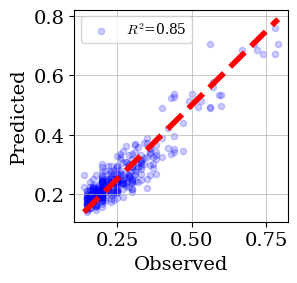

In [52]:
dpi = 600               # Change as you wish
b_cm = 7                       # Change as you wish
h_cm = 7                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm
label_x = 'Observed'            # Change as you wish
label_y = 'Predicted'           # Change as you wish
size_label = 14                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 14                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish
size_line = 4           # Change as you wish
style_line = '--'       # Change as you wish
color_line = 'red'      # or hexadecimal. Change as you wish
labels_legend = [rf'$R^2$={r2_fib_model_2020:.2f}']   # Change as you wish
size_legend = 10                # Change as you wish
location_legend = 'upper left'  # Change as you wish - 'best' look up by the best fit
fig, ax = plt.subplots(figsize=(b_input, h_input))
lims = [
            min(data['output:-w_exp-(mm)'].min(), data['wnum'].min()),
            max(data['output:-w_exp-(mm)'].max(), data['wnum'].max())
        ]

# Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

# Plot data y = x and scatter
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["output:-w_exp-(mm)"], data["wnum"], alpha=0.2, color='blue', s=20, label=labels_legend[0])
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_scatter-line_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### KDE numerical model - original model

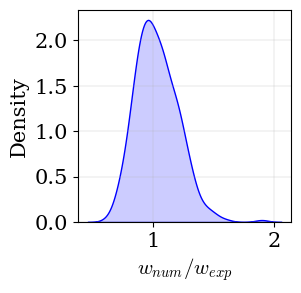

In [53]:
dpi = 600               

b_cm = 7            
h_cm = 7
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = 'Density'
label_x = '$w_{num}/w_{exp}$'   
size_label = 15
color_label = 'black'
size_axis = 15
color_axis = 'black'           

labels_legend = ['fib Model 2020']   
size_legend = 9                
location_legend = 'upper right'  

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=data, x='wnum/wexp', fill=True, alpha=0.2, color='blue', ax=ax, label=labels_legend[0])
# ax.legend(fontsize=size_legend, loc=location_legend)
fig.savefig(f'z_kde_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Goodness-of-fit

### Anderson-Darling test

Normal

In [54]:
# alpha = 5
# res = sci.stats.anderson(np.log(data['wnum/wexp']), dist="norm")
# stat = res.statistic
# crit = res.critical_values[res.significance_level == alpha][0]
# decision = "Accepted" if stat < crit else "Rejected"
# print(f"AD Statistic: {stat:.4f}")
# print(f"Critical Value at {alpha}% significance level: {crit:.4f}")
# print(f"Null Hypothesis: {decision}")

### Kolmogorov-Smirnov test

t-student

In [55]:
x = data['wnum/wexp'].values
df, loc, scale = sci.stats.t.fit(x)
print(f"\nFitted Student-t parameters:\nDegrees of freedom: {df:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 't', args=(df, loc, scale))
print("\nKolmogorov-Smirnov Test for Student-t Distribution:")
print(f"Student-t KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Student-t parameters:
Degrees of freedom: 14.1663, Location: 1.0277, Scale: 0.1619

Kolmogorov-Smirnov Test for Student-t Distribution:
Student-t KS statistic: 0.0491
p-value: 0.3715


Normal

In [56]:
x = data['wnum/wexp'].values
loc, scale = sci.stats.norm.fit(x)
print(f"\nFitted Normal parameters:\nLocation: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'norm', args=(loc, scale))
print("\nKolmogorov-Smirnov Test for Normal Distribution:")
print(f"Normal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Normal parameters:
Location: 1.0331, Scale: 0.1754

Kolmogorov-Smirnov Test for Normal Distribution:
Normal KS statistic: 0.0547
p-value: 0.2505


Log-normal

In [57]:
x = data['wnum/wexp'].values
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.2042, Location: 0.1839, Scale: 0.8316

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0267
p-value: 0.9627


### Genetate statistics for Lognormal

In [58]:
mu = np.log(scale)
sigma = shape

mean = loc + np.exp(mu + 0.5*sigma**2)
var = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std = np.sqrt(var)

print("\nLognormal Distribution Moments after fitting:")
print(f"Mean = {mean:.3f}")
print(f"Std  = {std:.3f}")


Lognormal Distribution Moments after fitting:
Mean = 1.033
Std  = 0.175


#### Generate synthetic data

In [59]:
sigma = np.sqrt(np.log(1 + (std / mean)**2))
mu = np.log(mean) - 0.5 * sigma**2

shape = sigma
loc = 0.0
scale = np.exp(mu)

print(f"shape = {shape:.4f}")
print(f"loc   = {loc:.4f}")
print(f"scale = {scale:.4f}")

n_samples = 20000
synthetic_data = sci.stats.lognorm.rvs(s=shape, loc=loc, scale=scale, size=n_samples)

shape = 0.1684
loc   = 0.0000
scale = 1.0185


In [60]:
# Double check the fit on the synthetic data
x = synthetic_data.copy()
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.1693, Location: 0.0036, Scale: 1.0119

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0031
p-value: 0.9918


#### Synthetic data versus original data

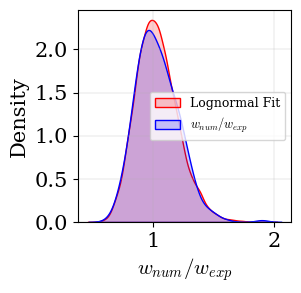

In [61]:
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=synthetic_data, fill=True, alpha=0.2, color='red', label='Lognormal Fit', ax=ax)
sns.kdeplot(data=list(data['wnum/wexp']), fill=True, alpha=0.2, color='blue', label='$w_{num}/w_{exp}$', ax=ax)
ax.legend(fontsize=size_legend, loc='center right')
fig.savefig(f'z_kde_{name}_gt_versus_lognormal.png', dpi=dpi, bbox_inches='tight')
plt.show()